# Simulate two non-linear sensors

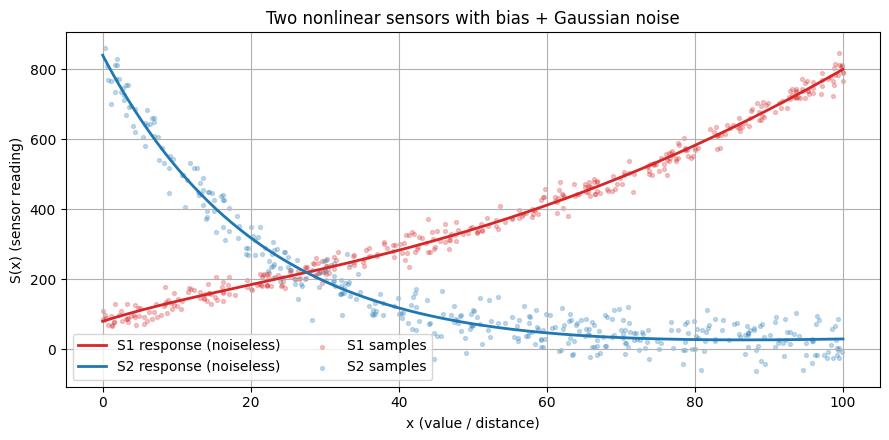

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


def s1_forward(x: np.ndarray) -> np.ndarray:
    """Nonlinear, monotonically increasing response curve."""
    x = np.asarray(x)
    return 120.0 * (1.0 - np.exp(-x / 18.0)) + 0.06 * x**2


def s2_forward(x: np.ndarray) -> np.ndarray:
    """Nonlinear, monotonically decreasing response curve."""
    x = np.asarray(x)
    return 900.0 * np.exp(-x / 22.0) + 0.8 * x


class NonlinearSensor:
    def __init__(self, name: str, forward_fn, bias: float, sigma: float):
        self.name = name
        self.forward_fn = forward_fn
        self.bias = float(bias)
        self.sigma = float(sigma)

    def sample(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x)
        noise = rng.normal(loc=0.0, scale=self.sigma, size=x.shape)
        return self.forward_fn(x) + self.bias + noise

    def calibration_samples(self, n: int, x_min: float, x_max: float):
        x = rng.uniform(x_min, x_max, size=n)
        s = self.sample(x)
        return x, s


# 1) Define sensors (different bias + noise)
x_min, x_max = 0.0, 100.0
sensor1 = NonlinearSensor(name="S1", forward_fn=s1_forward, bias=+80.0, sigma=20.0)
sensor2 = NonlinearSensor(name="S2", forward_fn=s2_forward, bias=-60.0, sigma=40.0)

# 2) Visualize response curves (noiseless curve + noisy samples)
x_grid = np.linspace(x_min, x_max, 400)

n_calib = 4000
x1_cal, s1_cal = sensor1.calibration_samples(n=n_calib, x_min=x_min, x_max=x_max)
x2_cal, s2_cal = sensor2.calibration_samples(n=n_calib, x_min=x_min, x_max=x_max)

plt.figure(figsize=(9, 4.5))
plt.plot(x_grid, s1_forward(x_grid) + sensor1.bias, color="tab:red", lw=2, label="S1 response (noiseless)")
plt.plot(x_grid, s2_forward(x_grid) + sensor2.bias, color="tab:blue", lw=2, label="S2 response (noiseless)")

plt.scatter(x1_cal[::10], s1_cal[::10], s=8, alpha=0.25, color="tab:red", label="S1 samples")
plt.scatter(x2_cal[::10], s2_cal[::10], s=8, alpha=0.25, color="tab:blue", label="S2 samples")

plt.xlabel("x (value / distance)")
plt.ylabel("S(x) (sensor reading)")
plt.title("Two nonlinear sensors with bias + Gaussian noise")
plt.grid(True)
plt.legend(ncols=2)
plt.tight_layout()
plt.show()

In [2]:
sensor1.bias, sensor1.sigma, sensor2.bias, sensor2.sigma

(80.0, 20.0, -60.0, 40.0)

In [3]:
x1_cal

array([77.39560486, 43.88784398, 85.85979199, ..., 45.3191935 ,
       33.96624638, 18.03537216])

In [4]:
s1_cal

array([536.96413726, 275.15735754, 668.34845366, ..., 328.38002248,
       262.53735626, 147.24541009])

In [5]:
x1_cal.shape, s1_cal.shape

((4000,), (4000,))

# Build an Inverse Sensor Model (ISM) for each sensor

RMSE(ISMs, dict LUT on eval): S1 ≈ 3.28 x-units, S2 ≈ 15.25 x-units
Noise estimate from eval residuals (x-hat domain):
  S1: RMSE=3.28  → weight w1=1/MSE=0.0932
  S2: RMSE=15.25  → weight w2=1/MSE=0.0043


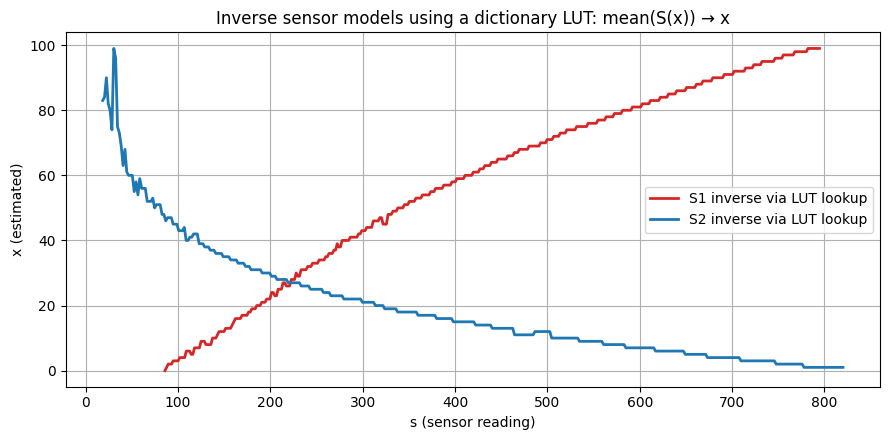

In [6]:
# Inverse Sensor Model (ISM) as a simple dictionary LUT: mean(S(x)) -> x
#
# Build step:
#   For each fixed x, measure the sensor multiple times and store the mean sensor reading.
#   This gives a LUT entry:  mean(S(x))  ->  x
#
# Query step (very simple, easy to follow):
#   Given a measured sensor value s, scan all LUT keys and return the x whose key is closest to s.


def build_lut_mean_s_to_x(sensor: NonlinearSensor, x_values: np.ndarray, n_repeats: int):
    """Return a dict that maps mean sensor reading to x, plus the key/value arrays for plotting."""
    lut = {}
    s_means = []
    x_out = []

    for x in x_values:
        x = float(x)
        s_samples = sensor.sample(np.full(n_repeats, x))
        s_mean = float(np.mean(s_samples))

        lut[s_mean] = x
        s_means.append(s_mean)
        x_out.append(x)

    return lut, np.array(s_means, dtype=float), np.array(x_out, dtype=float)


def lut_lookup_nearest(lut: dict, s_query: float):
    """Brute-force nearest-neighbor lookup in the dict (simple for teaching)."""
    best_s_key = None
    best_x = None
    best_dist = float("inf")

    for s_key, x_val in lut.items():
        dist = abs(s_query - s_key)
        if dist < best_dist:
            best_dist = dist
            best_s_key = s_key
            best_x = x_val

    return best_x, best_s_key, best_dist


def lut_predict(lut: dict, s_query: np.ndarray) -> np.ndarray:
    s_query = np.asarray(s_query, dtype=float)
    out = np.empty_like(s_query, dtype=float)

    for i, s in enumerate(s_query):
        out[i] = lut_lookup_nearest(lut, float(s))[0]

    return out


# Build LUTs: use a fixed x-grid and multiple measurements per x
n_repeats = 50
x_lut_grid = np.arange(x_min, x_max + 1.0, 1.0)

lut1, s1_keys, x1_vals = build_lut_mean_s_to_x(sensor1, x_lut_grid, n_repeats=n_repeats)
lut2, s2_keys, x2_vals = build_lut_mean_s_to_x(sensor2, x_lut_grid, n_repeats=n_repeats)

# Quick quality estimate of the inverse models (evaluate on noisy measurements)
n_eval = 800
x_eval = rng.uniform(x_min, x_max, size=n_eval)

s1_eval = sensor1.sample(x_eval)
s2_eval = sensor2.sample(x_eval)

x1_eval_hat = lut_predict(lut1, s1_eval)
x2_eval_hat = lut_predict(lut2, s2_eval)

err1_eval = x1_eval_hat - x_eval
err2_eval = x2_eval_hat - x_eval

# For inverse-variance fusion we need a noise level per sensor.
# Here we estimate it from eval residuals in x-domain.
# As an estimate of noise level we use MSE of the residuals

eps = 1e-12
mse1 = float(np.mean(err1_eval**2))
mse2 = float(np.mean(err2_eval**2))
rmse1 = float(np.sqrt(mse1))
rmse2 = float(np.sqrt(mse2))
w1 = 1.0 / (mse1 + eps)
w2 = 1.0 / (mse2 + eps)
print(f"RMSE(ISMs, dict LUT on eval): S1 ≈ {rmse1:.2f} x-units, S2 ≈ {rmse2:.2f} x-units")
print(
    "Noise estimate from eval residuals (x-hat domain):\n"
    f"  S1: RMSE={rmse1:.2f}  → weight w1=1/MSE={w1:.4f}\n"
    f"  S2: RMSE={rmse2:.2f}  → weight w2=1/MSE={w2:.4f}"
)

# Visualization: inverse curve x(s) computed via LUT lookup

def plot_inverse(sensor_name: str, s_keys: np.ndarray, x_vals: np.ndarray, lut: dict, color: str):
    s_lo, s_hi = np.percentile(s_keys, [0.5, 99.5])
    s_grid = np.linspace(s_lo, s_hi, 400)
    x_pred = lut_predict(lut, s_grid)

    #plt.scatter(s_keys, x_vals, s=100, alpha=0.5, label=f"{sensor_name} LUT entries (mean s → x)")
    plt.plot(s_grid, x_pred, lw=2, label=f"{sensor_name} inverse via LUT lookup", color=color)


plt.figure(figsize=(9, 4.5))
plot_inverse("S1", s1_keys, x1_vals, lut1, color="tab:red")
plot_inverse("S2", s2_keys, x2_vals, lut2, color="tab:blue")
plt.xlabel("s (sensor reading)")
plt.ylabel("x (estimated)")
plt.title("Inverse sensor models using a dictionary LUT: mean(S(x)) → x")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
lut1

{84.15880198247683: 0.0,
 87.48670665872531: 1.0,
 90.63250138116344: 2.0,
 96.89078228428129: 3.0,
 104.73805787664031: 4.0,
 113.3322693079182: 5.0,
 112.84714596638969: 6.0,
 121.3070659653279: 7.0,
 132.34143688181973: 8.0,
 127.88360689329437: 9.0,
 140.7188436724118: 10.0,
 143.52645921282843: 11.0,
 145.15664246137555: 12.0,
 155.33365094733645: 13.0,
 158.4384396741724: 14.0,
 159.40614475201724: 15.0,
 164.03269235582923: 16.0,
 171.97852526784388: 17.0,
 179.43130377095474: 18.0,
 179.81949677360865: 19.0,
 188.40360581625242: 20.0,
 190.5183175118901: 21.0,
 198.8463830709968: 22.0,
 203.90133706014353: 23.0,
 202.4375906653122: 24.0,
 209.70640922454055: 25.0,
 216.95497420012217: 26.0,
 214.90379173361205: 27.0,
 225.11329855499991: 28.0,
 228.78825977848803: 29.0,
 228.60753274536808: 30.0,
 235.58412989102882: 31.0,
 242.2113746363869: 32.0,
 247.01721176238797: 33.0,
 256.19116335296: 34.0,
 260.7416861494835: 35.0,
 264.53519019310374: 36.0,
 270.15187147869005: 37.0,


In [8]:
lut_lookup_nearest(lut1, 87.0)

(1.0, 87.48670665872531, 0.4867066587253106)

# Use ISM for sensor data fusion

RMSE (test):
  only S1:  3.08
  only S2:  14.55
  IVW    :   2.99

Fusion weights (constant): w1=0.0932, w2=0.0043  (normalized: 0.96/0.04)


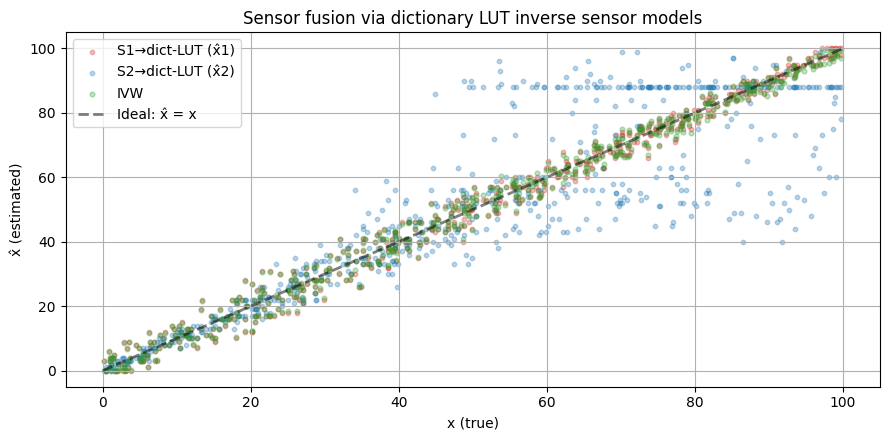

In [10]:
# Fusion: dict-LUT provides x̂1, x̂2; fuse via an inverse-variance weighted mean
#
# In practice you typically estimate each sensor's effective variance (or MSE)
# from a calibration/eval phase, then keep the weights fixed (or adapt them).
# Here we use the MSE-based weights w1, w2 computed above from eval residuals.

n_test = 600
x_true = rng.uniform(x_min, x_max, size=n_test)

s1_samples = sensor1.sample(x_true)
s2_samples = sensor2.sample(x_true)

x1_hat = lut_predict(lut1, s1_samples)
x2_hat = lut_predict(lut2, s2_samples)

# Inverse-variance (here: inverse-MSE) fusion
x_fused = (w1 * x1_hat + w2 * x2_hat) / (w1 + w2)

err1 = x1_hat - x_true
err2 = x2_hat - x_true
errf = x_fused - x_true

rmse_test_1 = float(np.sqrt(np.mean(err1**2)))
rmse_test_2 = float(np.sqrt(np.mean(err2**2)))
rmse_test_f = float(np.sqrt(np.mean(errf**2)))

print(
    "RMSE (test):\n"
    f"  only S1:  {rmse_test_1:.2f}\n"
    f"  only S2:  {rmse_test_2:.2f}\n"
    f"  IVW    :   {rmse_test_f:.2f}\n\n"
    f"Fusion weights (constant): w1={w1:.4f}, w2={w2:.4f}  (normalized: {w1/(w1+w2):.2f}/{w2/(w1+w2):.2f})"
)

plt.figure(figsize=(9, 4.5))
plt.scatter(x_true, x1_hat, s=10, alpha=0.3, label="S1→dict-LUT (x̂1)", color="tab:red")
plt.scatter(x_true, x2_hat, s=10, alpha=0.3, label="S2→dict-LUT (x̂2)", color="tab:blue")
plt.scatter(x_true, x_fused, s=12, alpha=0.3, label="IVW", color="tab:green")

plt.plot([x_min, x_max], [x_min, x_max], "k--", lw=2, label="Ideal: x̂ = x", alpha=0.5)
plt.xlabel("x (true)")
plt.ylabel("x̂ (estimated)")
plt.title("Sensor fusion via dictionary LUT inverse sensor models")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Fusion example for a single data point

In [11]:
# Small single example
# (uses the constant inverse-variance weights w1, w2 estimated above)

x0 = 10.0
s1_0 = float(sensor1.sample(np.array([x0]))[0])
s2_0 = float(sensor2.sample(np.array([x0]))[0])

x1_0, s1_key, d1 = lut_lookup_nearest(lut1, s1_0)
x2_0, s2_key, d2 = lut_lookup_nearest(lut2, s2_0)
x_f0 = float((w1 * x1_0 + w2 * x2_0) / (w1 + w2))

print(f"x_true={x0:.2f}")
print(f"S1 measures s={s1_0:.2f}  → closest key={s1_key:.2f} (|Δ|={d1:.2f}) → x̂1={x1_0:.2f}")
print(f"S2 measures s={s2_0:.2f}  → closest key={s2_key:.2f} (|Δ|={d2:.2f}) → x̂2={x2_0:.2f}")
print(f"Fusion (inv-var): x̂={x_f0:.2f}  (w1={w1:.4f}, w2={w2:.4f})")

x_true=10.00
S1 measures s=142.30  → closest key=143.53 (|Δ|=1.23) → x̂1=11.00
S2 measures s=539.65  → closest key=546.20 (|Δ|=6.55) → x̂2=9.00
Fusion (inv-var): x̂=10.91  (w1=0.0932, w2=0.0043)


# Histogram of error distributions: S1 vs. S2. vs. IVW

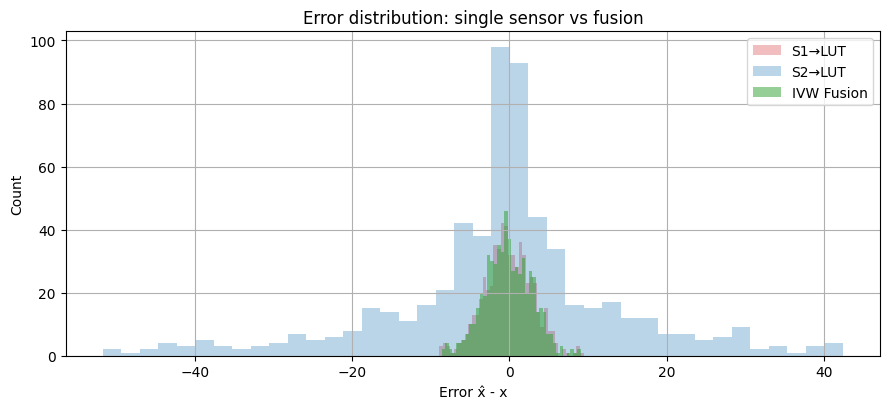

In [15]:
# (Optional) Error distributions as a histogram
plt.figure(figsize=(9, 4.2))
plt.hist(err1, bins=40, alpha=0.3, label="S1→LUT", color="tab:red")
plt.hist(err2, bins=40, alpha=0.3, label="S2→LUT", color="tab:blue")
plt.hist(errf, bins=40, alpha=0.5, label="IVW Fusion", color="tab:green")
plt.xlabel("Error x̂ - x")
plt.ylabel("Count")
plt.title("Error distribution: single sensor vs fusion")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()